#### Imports / configuration loading

In [1]:
# Reload imports if needed
# import source
# import importlib
# importlib.reload(source.results_analysis)
# importlib.reload(source.train_predictive_models)
# importlib.reload(source.predictive_models)
# importlib.reload(source.exploration)
# importlib.reload(source.map_loader)

In [4]:

from source import agents, exploration, predictive_models
from source.map_loader import Env
from source.train_predictive_models import process_input, runSGD, one_hot_encode
from source.results_analysis import metrics_predict_map,print_metrics,latent_space_PCA
from pathlib import Path
import source.results_analysis as results_analysis
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import json
import os
import textwrap
from tqdm import tqdm
import pandas as pd
import seaborn as sns

map_files = ["8x8_colors.txt","20x20_colors.txt", "50x50_colors.txt"] 
map_labels = ["8x8_colors","20x20_colors", "50x50_colors"] 
dims = [[8,8],[20,20],[50,50]]
map_types = ["color","color","color"]
config_files = ["egocentric_empty_7x7view_rnn_separate_action.json"]
seeds = [77243, 798315, 101125]
n_action_seq = [1,2,4,8,16]
configs = []

for config in config_files:
    with open(f"configs/multiple_action_sequences/{config}", 'r') as file: 
       configs.append(json.load(file))

####  Data generation

In [41]:
loaded_data = [{k3: None for k3 in seeds} for i in range(len(map_files))] 
observation_spaces = {"egocentric": exploration.exploration_egocentric,"allocentric":exploration.exploration_allocentric}

config = configs[0]
observation_space = config["observation_space"]

data_keys = ['img_train', 'pos_train', 'dir_train', 'img_test', 'pos_test', 'dir_test']
for c in range(len(map_files)):
    with open(f"maps/{map_files[c]}", 'r') as file:
        map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    if (map_types[c]=="color"):
        with open(f"maps/colors/{map_files[c]}", 'r') as file:
            color_map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    else:
        color_map = None
    env = Env(map,dims[c],tuple(config['start_pos']),seed=config['env_seed'],render_mode="rgb_array",agent_view_size=config['egocentric_view_size'])
    env.reset(seed=env.env_seed)
    for seed in seeds:
        if observation_space == "egocentric":
            agent_type = ["random", [0.3333, 0.3333, 0.3334],seed]
        elif observation_space == "allocentric":
            agent_type = ["random", [0.25, 0.25, 0.25, 0.25], seed]

        outfolder = f"exploration_data/multiple_action_sequences/{map_labels[c]}"
        outdir = f"{outfolder}/{seed}_exploration_data.npz"
        Path(outfolder).mkdir(parents=True, exist_ok=True)
        print(f"Setting:{c}, {observation_space}, {seed}")
        try:
            with np.load(outdir) as data:
                loaded_data[c][seed] = [data[k] for k in data_keys]
                print ("Successfully loaded data!")
        except (FileNotFoundError, Exception):
            config['agent_type'][2] = seed
            env = Env(map,dims[c],tuple(config['start_pos']),seed=seed,render_mode="rgb_array",agent_view_size=config['egocentric_view_size'],colors=color_map)
            env.reset(seed=env.env_seed)
            loaded_data[c][seed] = observation_spaces[observation_space](
            env,
            agent_type=agent_type,
            n_steps_train=config['number_steps_train'],
            n_steps_test=config['number_steps_test'],
            n_restart_train=config['num_random_position_restarts_train'],
            n_restart_test=config['num_random_position_restarts_test'],
            rgb_rep=True)
            exploration_data = loaded_data[c][seed]
            np.savez_compressed(outdir, **dict(zip(data_keys, exploration_data)))
            print ("Exploration complete!")


Setting:0, egocentric, 77243
Successfully loaded data!
Setting:0, egocentric, 798315
Successfully loaded data!
Setting:0, egocentric, 101125
Successfully loaded data!
Setting:1, egocentric, 77243
Successfully loaded data!
Setting:1, egocentric, 798315
Successfully loaded data!
Setting:1, egocentric, 101125
Successfully loaded data!
Setting:2, egocentric, 77243
Successfully loaded data!
Setting:2, egocentric, 798315
Successfully loaded data!
Setting:2, egocentric, 101125
Successfully loaded data!


#### Training predictive models

In [39]:
print(n_act)
print(X_train[:-1,:-1].size(), train_actions.unfold(0, n_act, 1)[:-1].size())

1
torch.Size([15999, 147]) torch.Size([15999, 1])


In [ ]:
config_names = [config["config_name"] for config in configs]
loaded_models = {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names}
processed_inputs = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            X_train,X_test= torch.tensor(image_list_train, dtype=torch.int64),torch.tensor(image_list_test, dtype=torch.int64)

            target_train = X_train[n_act:]
            input_train = X_train[:-n_act]
            target_test = X_test[n_act:]
            input_test = X_test[:-n_act]

            train_actions = X_train[:,-1]
            test_actions = X_test[:,-1] 
            input_train = torch.cat((input_train[:,:-1],train_actions.unfold(0, n_act, 1)[:-1]),dim=1)
            input_test = torch.cat((input_test[:,:-1],test_actions.unfold(0, n_act, 1)[:-1]),dim=1)
            
            scaling_factor=1

            for config in configs:

                if config["observation_space"]=="allocentric":
                    img_width, img_height = config["map_dims"][0], config["map_dims"][1]
                else:
                    img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]

                input_train_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_train])
                target_train_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_train])
                input_test_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_test])
                target_test_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_test])


                processed_inputs[n_act][config["config_name"]][c][seed] = [input_train_processed, target_train_processed]

                latent_size=config["latent_size"]
                hidden_fac=15
                img_channels=3
                input_size=input_train_processed.size(1)
                output_size = target_train_processed.size(1)
                torch.manual_seed(config["model_seed"])
                torch.use_deterministic_algorithms(True)
                train_flag = True
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                if config['model_type'] == "autoencoder_no_rnn":
                    model = predictive_models.AutoencoderWithoutRNN(input_size, output_size, hidden_fac, latent_size,device)
                elif config["model_type"]=="autoencoder_rnn":
                    model = predictive_models.AutoencoderWithRNN(input_size, output_size, hidden_fac, latent_size,device)
                elif config["model_type"]=="autoencoder_rnn_separate_action":
                    model = predictive_models.AutoencoderRNNSeparateAction(img_width*img_height*img_channels,input_size-img_width*img_height*img_channels, output_size, hidden_fac, latent_size,device)
                else:
                    model = predictive_models.AutoencoderInputs(img_width*img_height*img_channels,device)
                    train_flag = False
                n_epochs, batch_size = config['number_epochs'], config['batch_size']
                MODEL_PATH = f"trained_models/multiple_action_sequences/{n_act}_{config['predictive_model_path']}_{map_labels[c]}_{seed}.pt"
                METRICS_DIR = f"outputs/multiple_action_sequences/{n_act}/{config['predictive_model_path']}_{map_labels[c]}_{seed}"
                Path(METRICS_DIR).mkdir(parents=True, exist_ok=True)
                METRICS_PATH = f"{METRICS_DIR}/metrics.csv"
                if (config["load_trained_model_if_existent"] and os.path.exists(MODEL_PATH)) and config["model_type"]!="inputs":
                    try:
                        model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
                        print("Loaded model!")
                        with open(f"outputs/multiple_action_sequences/model_evaluation/{n_act}_{config['predictive_model_path']}_{map_labels[c]}_{seed}.json", "r") as f:
                            metrics = json.load(f)
                        train_flag = False
                    except (RuntimeError, KeyError, EOFError) as e:
                        print("Failed to load model - will proceed to training!")
                if train_flag:
                    tracked_losses_train, tracked_losses_test = runSGD(model, input_train_processed, target_train_processed, input_test_processed, target_test_processed, device=device, n_epochs=n_epochs, batch_size=batch_size,seed=config["model_seed"],notrain=(not config["train"]))
                    if (config['save_trained_model']):
                        torch.save(model.state_dict(), MODEL_PATH)

                dec_outputs = results_analysis.metrics_predict_rgb_map(model,config,device,scaling_factor,input_test_processed,target_test,tracked_losses_train,tracked_losses_test,outdir=METRICS_DIR)

                loaded_models[config["config_name"]][c][seed] = model 

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test


#### PCA on latent space 

In [ ]:
top_components = {k2: [{k3: [] for k3 in seeds} for i in range(len(map_files))] for k2 in config_names}

for config in configs:
    for c in tqdm(range(len(map_files))):
        for seed in tqdm(seeds):
            OUT_DIR = f"outputs/multiple_action_sequences/latent_space_PCA/{map_labels[c]}_{config['model_type']}/{seed}"
            input_train_processed = processed_inputs[config["config_name"]][c][seed][0]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            model = loaded_models[config["config_name"]][c][seed]
            # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
            all_latent_spaces = [(model.get_latent(i.view(1,-1))) for i in input_train_processed]
            latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
            latent_space_after_list = [i[1] for i in all_latent_spaces]
            if all(val is not None for val in latent_space_after_list):
                latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
            else:
                latent_space_after = None

            # if (config["model_type"] == "autoencoder_rnn"):
            #     latent_spaces = [[latent_space_before, "before_RNN"],[latent_space_after, "after_RNN"]]
            # else:
            latent_spaces = [[latent_space_before, ""]]
            print(config["config_name"], map_labels[c],seed)
            top_components[config["config_name"]][c][seed] = latent_space_PCA(latent_spaces,config,pos_list_train[:-1],dir_list_train[:-1],img_width,img_height,outdir=OUT_DIR)



In [28]:
all_labels

['50x50_colors_autoencoder_rnn_separate_action',
 '50x50_colors_autoencoder_rnn',
 '20x20_colors_autoencoder_rnn_separate_action',
 '20x20_colors_autoencoder_rnn',
 '50x50_colors_input_space',
 '20x20_colors_input_space']

##### Violin plots

In [ ]:
data_directories = [('outputs/multiple_action_sequences/latent_space_PCA',''),('outputs/variances_egocentic_input_spaces/latent_space_PCA','_input_space')]
labels_to_use= ["20x20_colors","50x50_colors","20x20_colors_autoencoder_rnn","50x50_colors_autoencoder_rnn","20x20_colors_autoencoder_rnn_separate_action","50x50_colors_autoencoder_rnn_separate_action"]

OUT_DIR_VAR = f"outputs/multiple_action_sequences/latent_space_PCA/"
Path(OUT_DIR_VAR).mkdir(parents=True, exist_ok=True)
values, labels = [],[]
metric_label = "variance of first 3 principal components" 
for data_directory,label in data_directories:
    print(sorted(os.listdir(data_directory),reverse=True))
    for map_label in sorted(os.listdir(data_directory),reverse=True):
        if map_label[-4:] != ".png" and map_label in labels_to_use:
            print(map_label)
            values.append([])
            labels.append(map_label+label)
            for seed in sorted(os.listdir(f"{data_directory}/{map_label}"),reverse=True):
                for filename in sorted(os.listdir(f"{data_directory}/{map_label}/{seed}"),reverse=True):
                    if filename.endswith('.json'):
                        path = os.path.join(Path(f"{data_directory}/{map_label}/{seed}"), filename)
                        with open(path, 'r') as f:
                            data = json.load(f)                                
                            values[-1] += [data["cumulative_variance"][2]]

wrapped_labels = [textwrap.fill(label, width=30) for label in labels]
df = pd.DataFrame([{'L': l, 'V': v} for l, vs in zip(wrapped_labels, values) for v in vs])
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='V', y='L',hue= 'L', palette='viridis', inner='box', linewidth=1.5)
plt.ylabel('Model type'); plt.xlabel(f"PCA {metric_label}")
plt.savefig(f"{OUT_DIR_VAR}/variance_violin_zoom.png", bbox_inches='tight')
plt.xlim(0, 1)
plt.savefig(f"{OUT_DIR_VAR}/variance_violin.png", bbox_inches='tight'); plt.clf()

['egocentric_empty_7x7view_rnn_50x50_colors', 'egocentric_empty_7x7view_rnn_20x20_colors', '50x50_colors_autoencoder_rnn_separate_action', '50x50_colors_autoencoder_rnn', '20x20_colors_autoencoder_rnn_separate_action', '20x20_colors_autoencoder_rnn']
50x50_colors_autoencoder_rnn_separate_action
50x50_colors_autoencoder_rnn
20x20_colors_autoencoder_rnn_separate_action
20x20_colors_autoencoder_rnn
['variance_violin_zoom.png', 'variance_violin.png', '8x8_walls', '8x8_empty', '8x8_colorswalls', '8x8_colors', '50x50_walls', '50x50_empty', '50x50_colorswalls', '50x50_colors', '20x20_walls', '20x20_empty', '20x20_colorswalls', '20x20_colors', '14x14_walls', '14x14_empty', '14x14_colorswalls', '14x14_colors']
50x50_colors
20x20_colors


<Figure size 800x600 with 0 Axes>

#### Environment cover

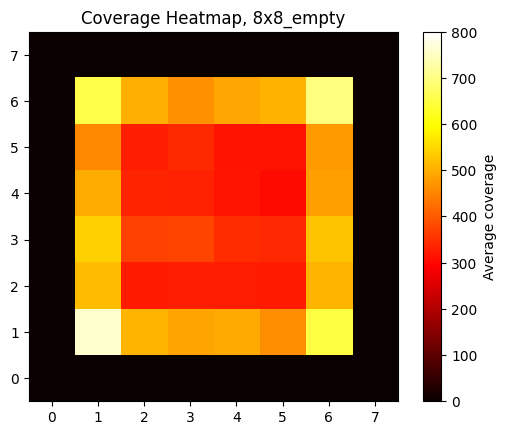

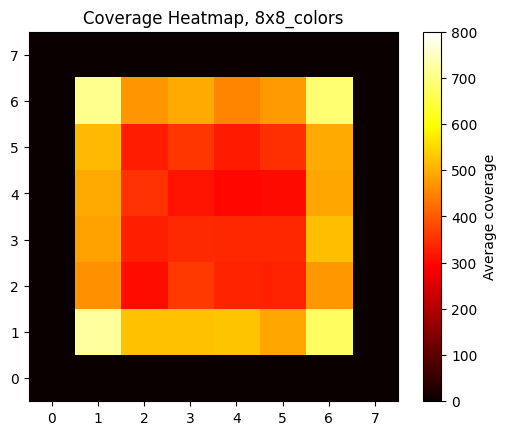

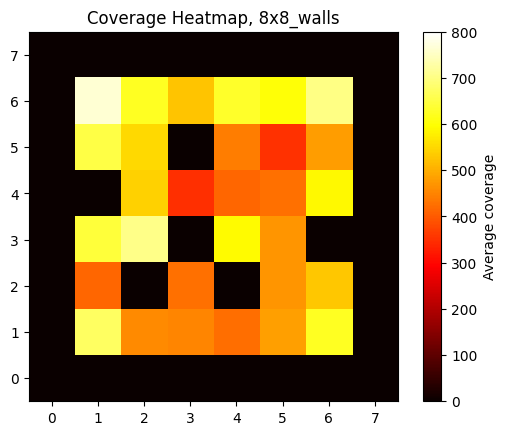

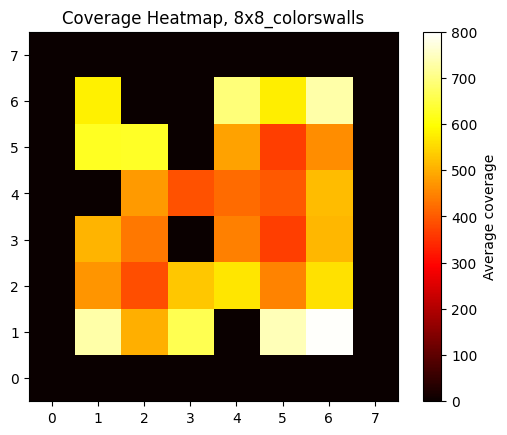

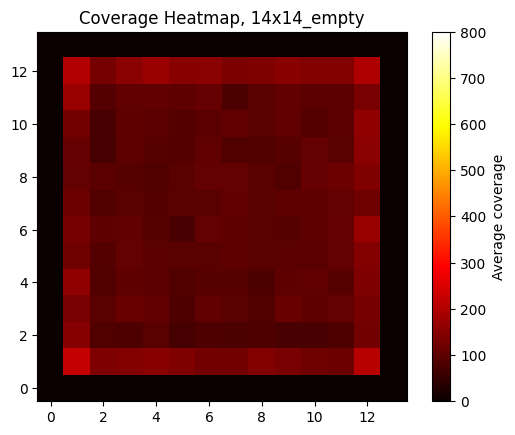

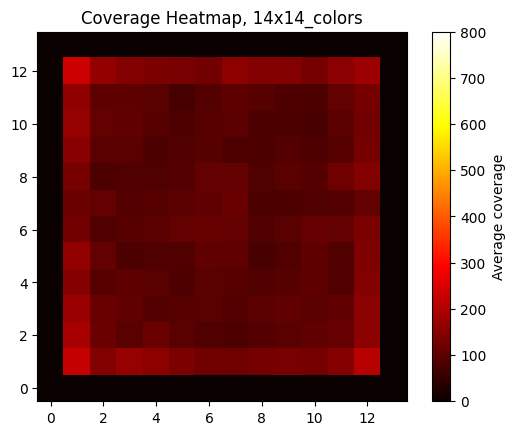

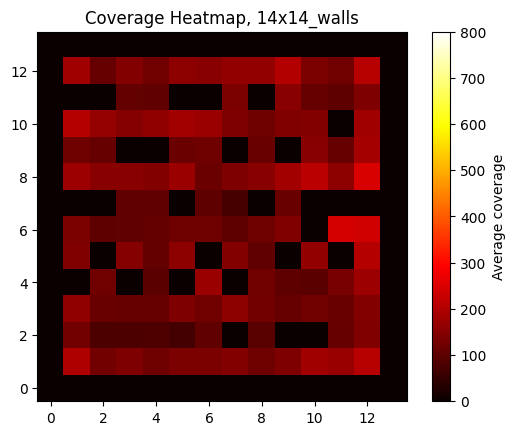

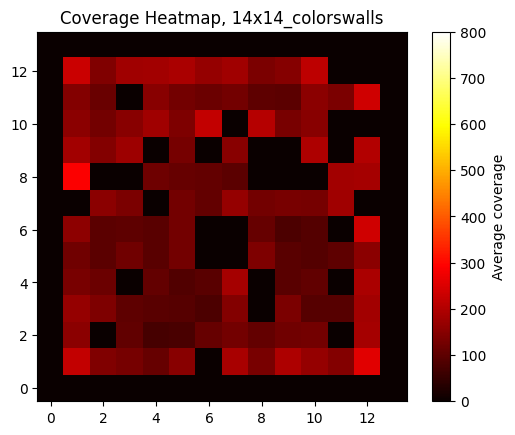

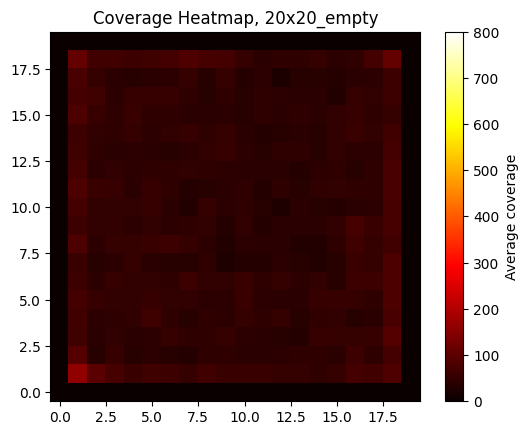

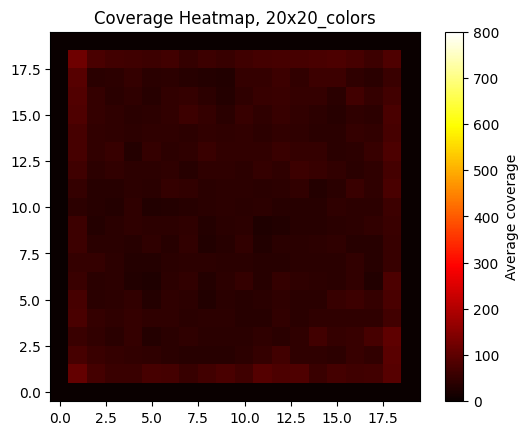

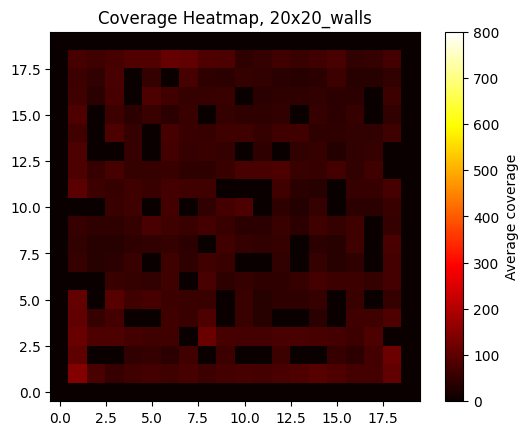

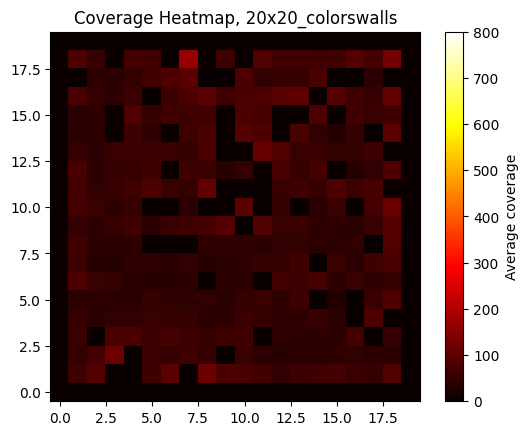

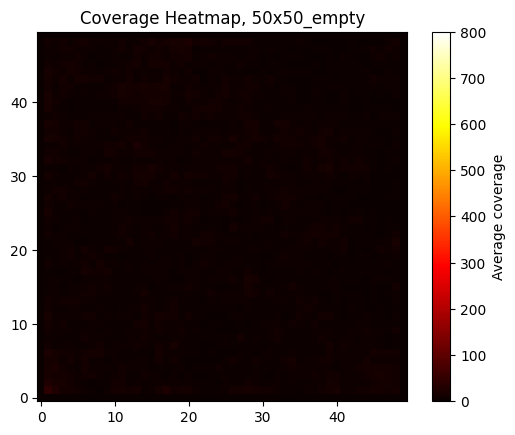

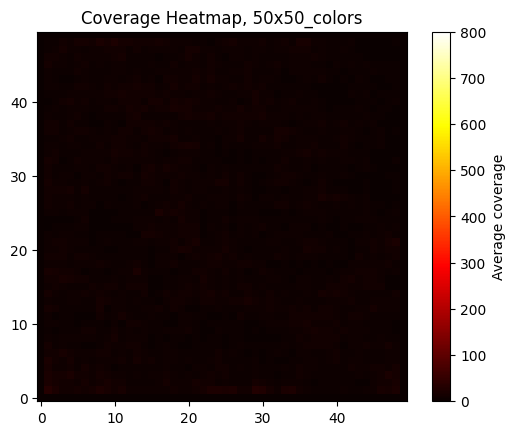

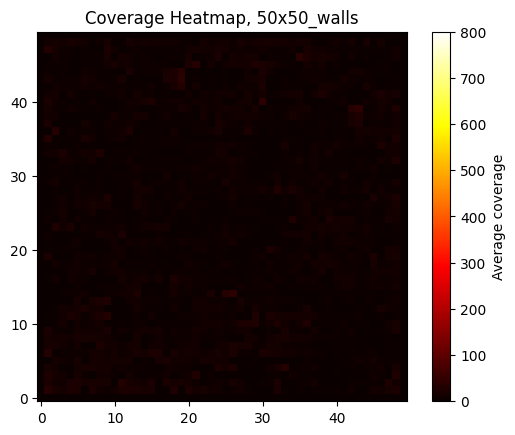

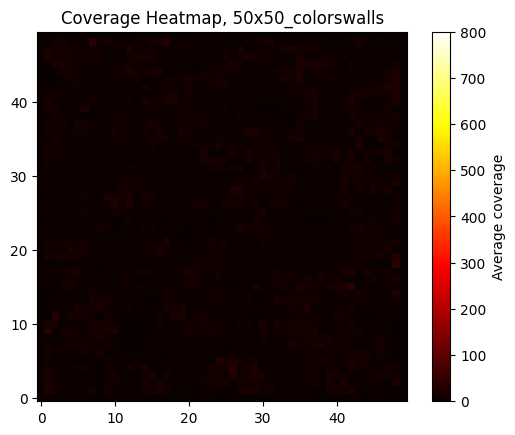

In [ ]:
for c in range(len(map_files)):
    map_width, map_height = dims[c]
    seeds_data = np.zeros((len(seeds), map_width, map_height))
    for s, seed in enumerate(seeds):
        coords = np.array(loaded_data[c][seed][1])
        if coords.size > 0:
            np.add.at(seeds_data[s], (coords[:,0], coords[:,1]), 1)
    avg_cover = np.mean(seeds_data, axis=0)

    plt.imshow(avg_cover, cmap='hot', interpolation='nearest',vmin=0,vmax=800)
    plt.imshow(avg_cover, cmap='hot', interpolation='nearest')
    plt.gca().invert_yaxis()
    plt.colorbar(label='Average coverage')
    plt.title(f"Coverage Heatmap, {map_labels[c]}")
    plt.show()

#### View env

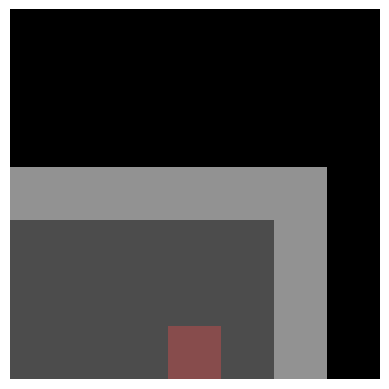

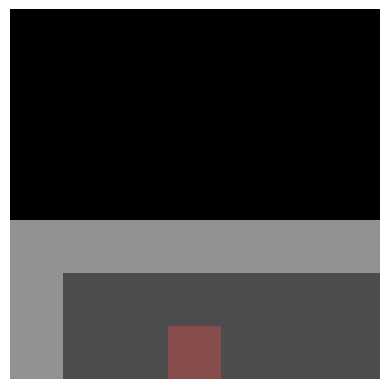

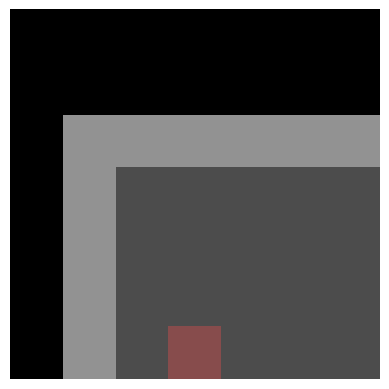

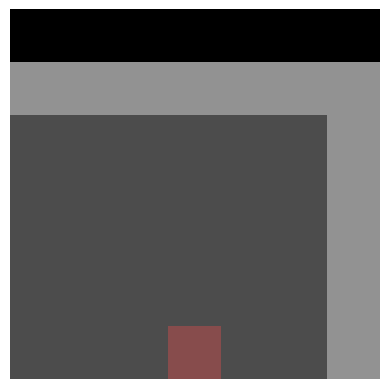

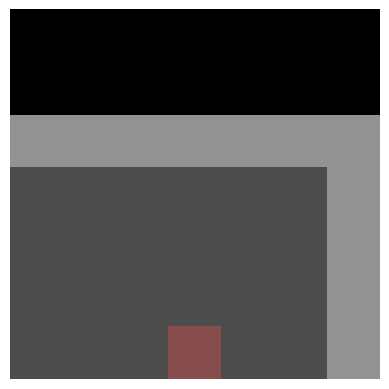

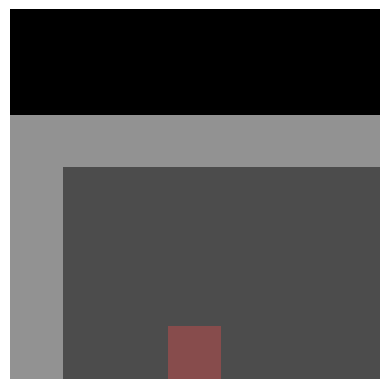

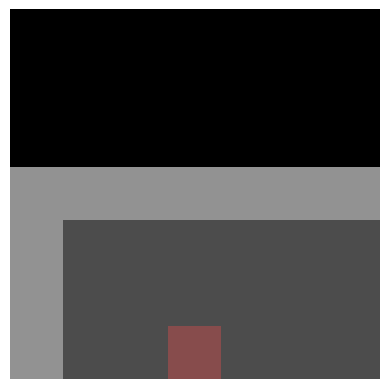

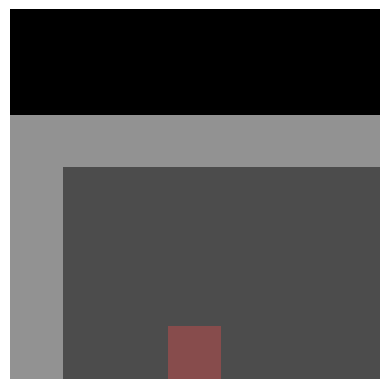

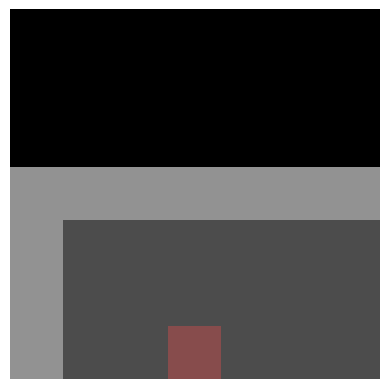

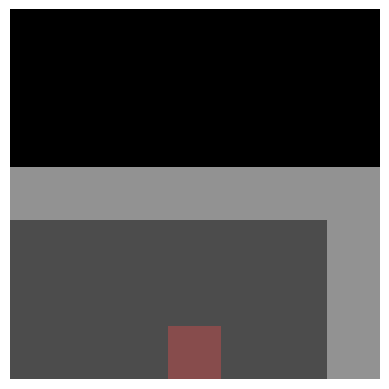

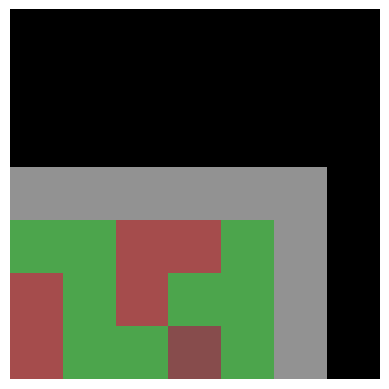

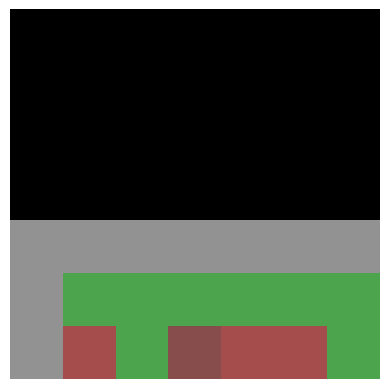

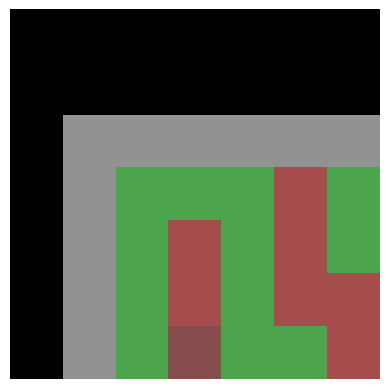

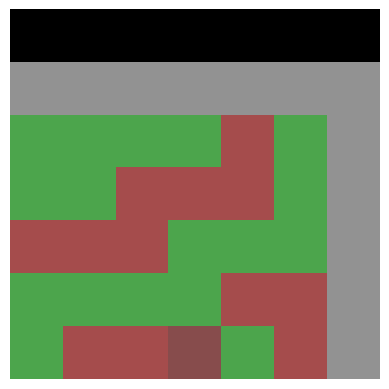

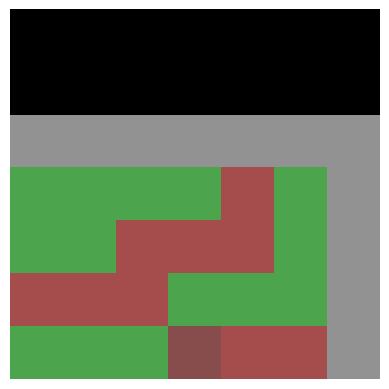

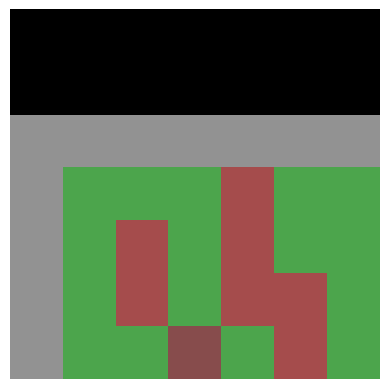

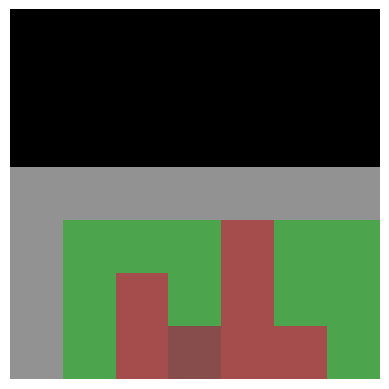

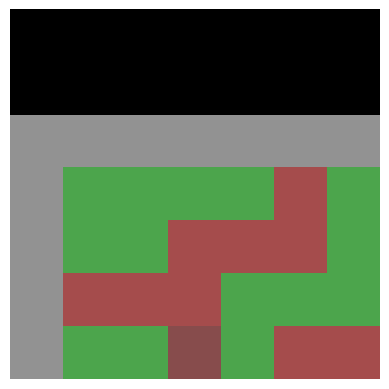

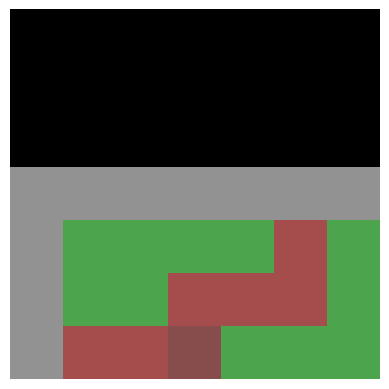

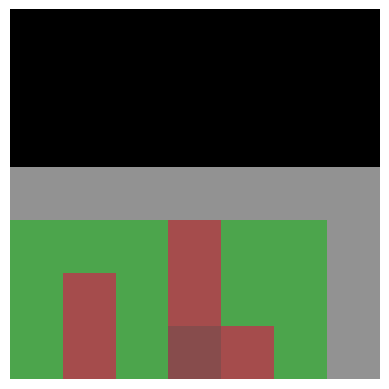

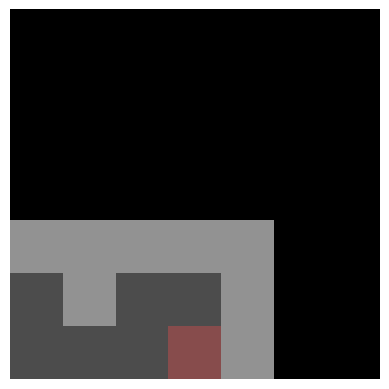

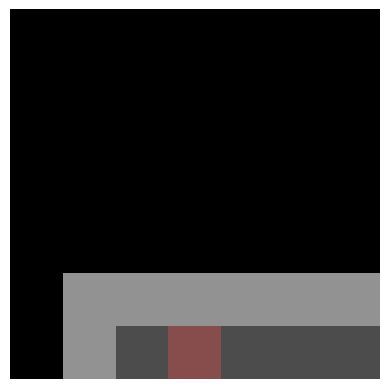

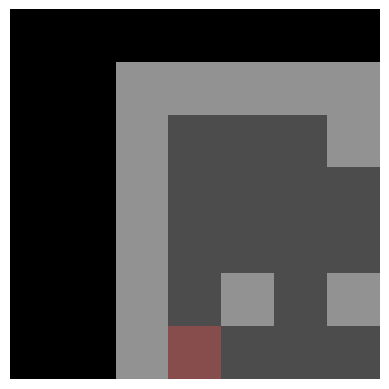

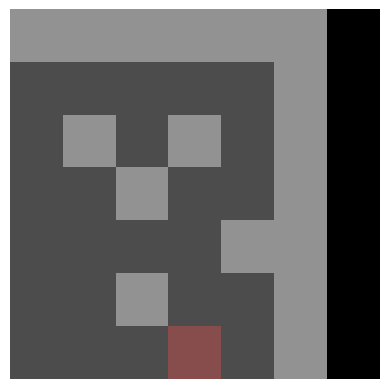

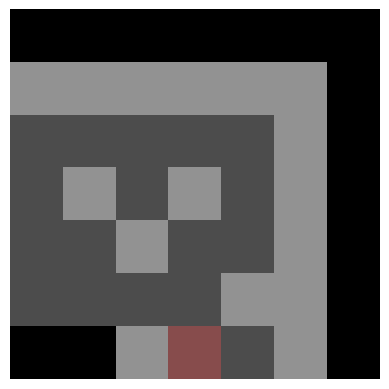

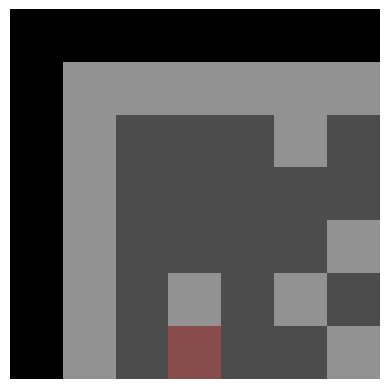

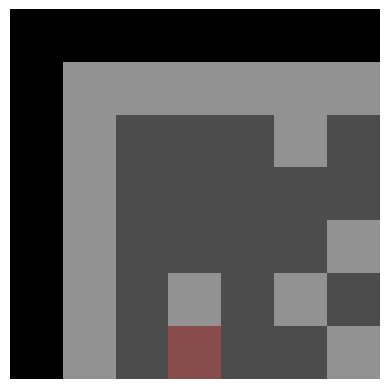

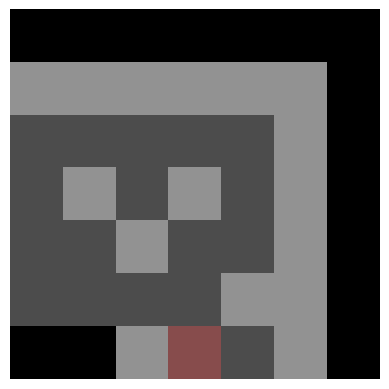

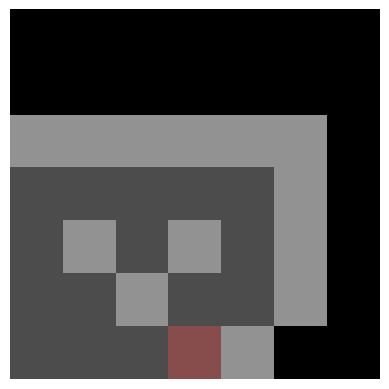

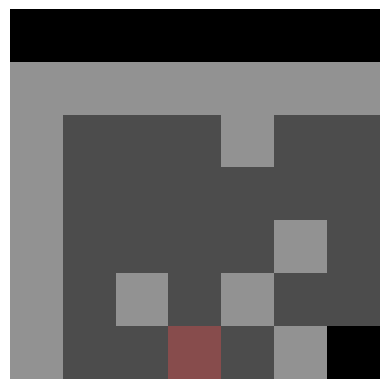

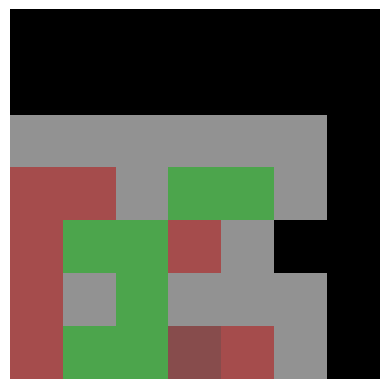

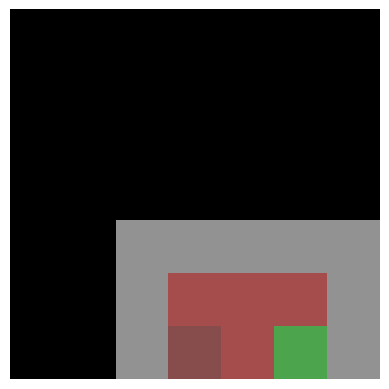

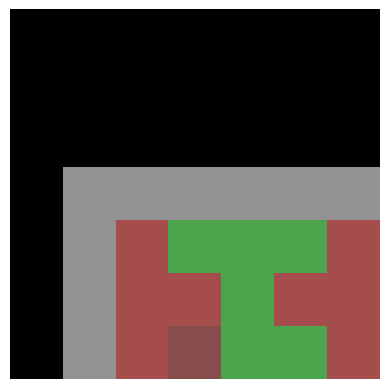

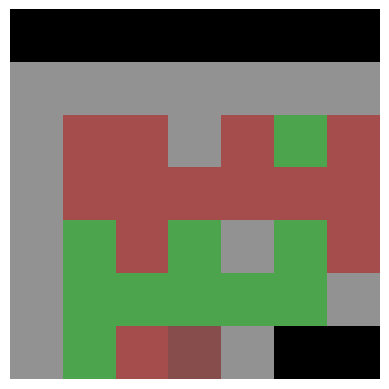

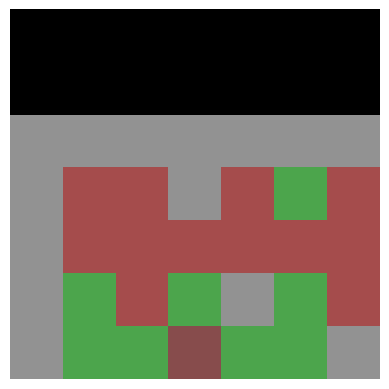

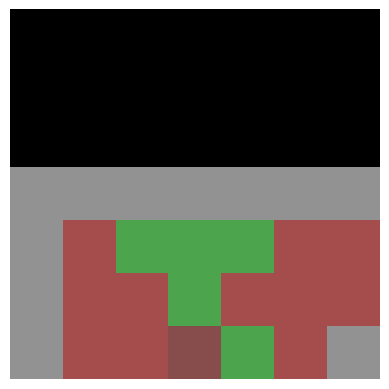

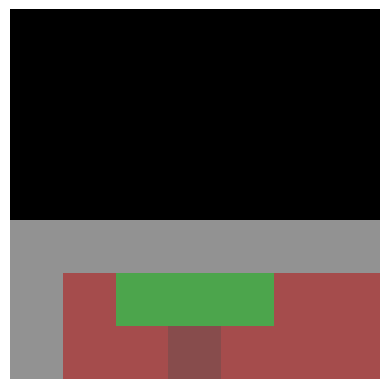

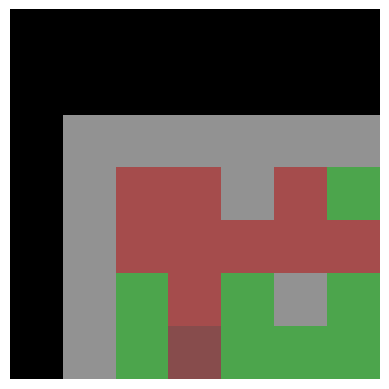

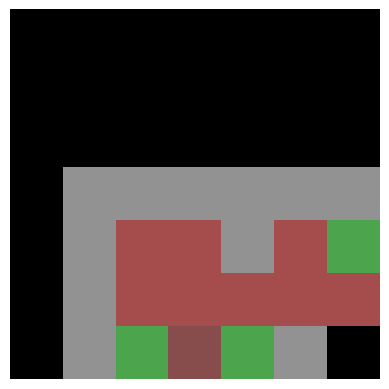

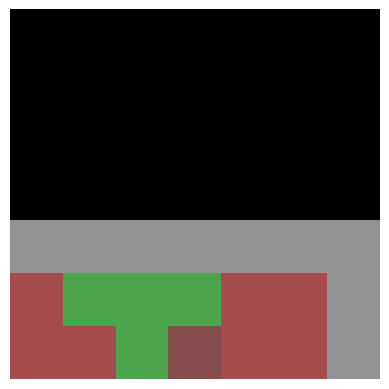

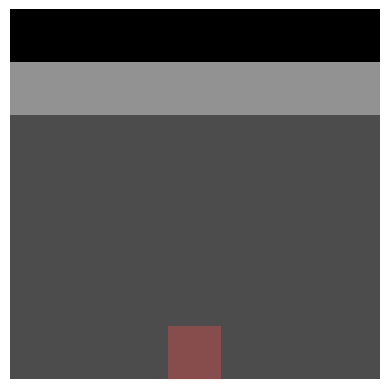

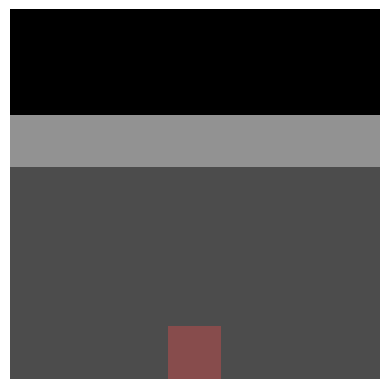

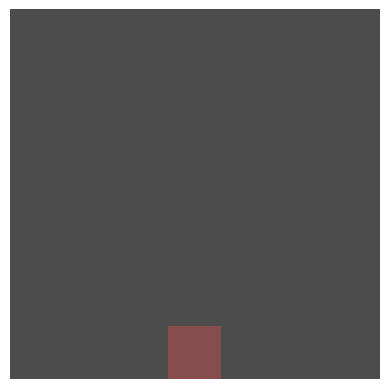

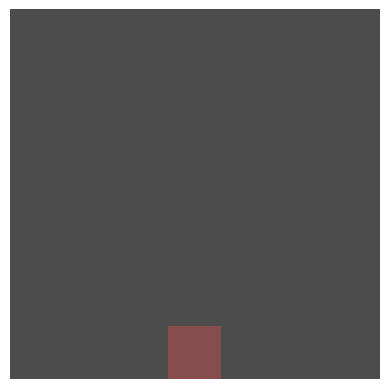

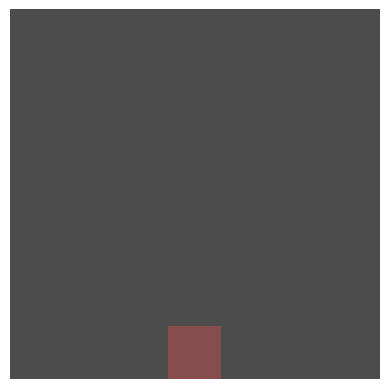

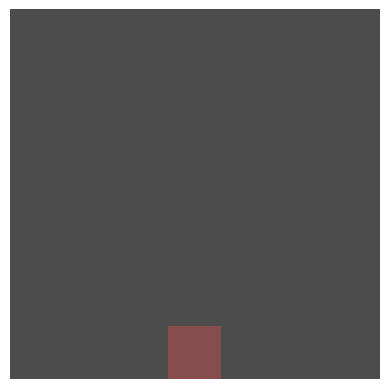

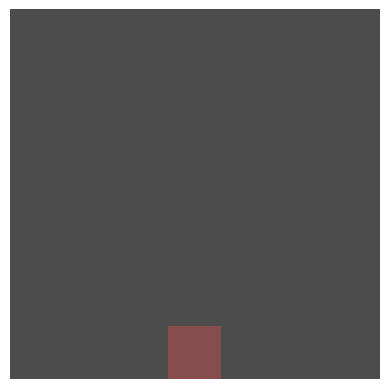

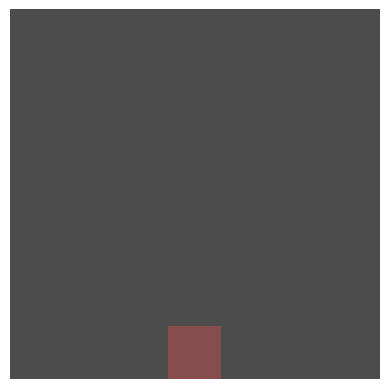

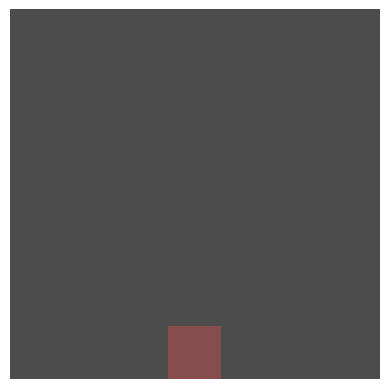

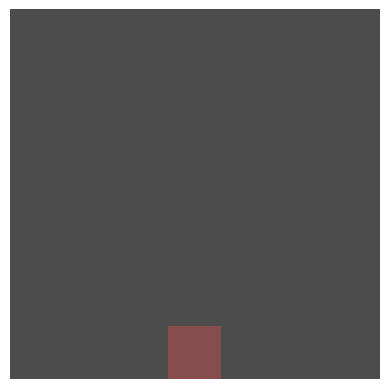

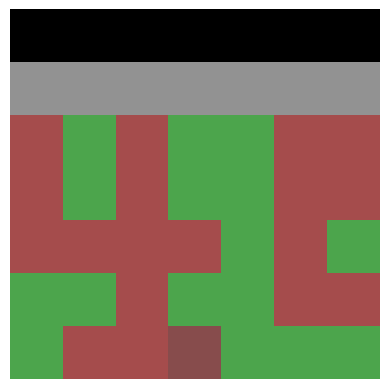

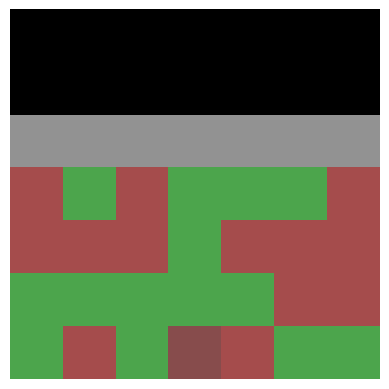

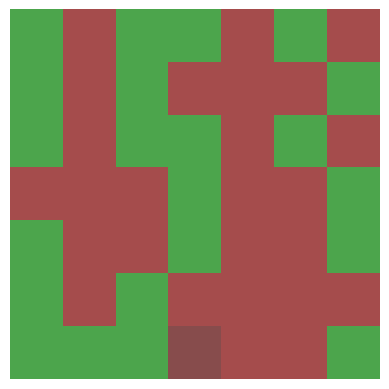

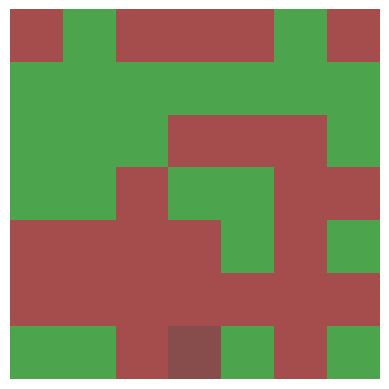

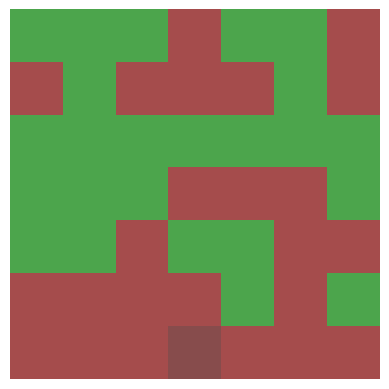

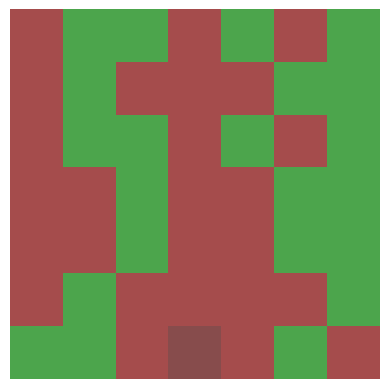

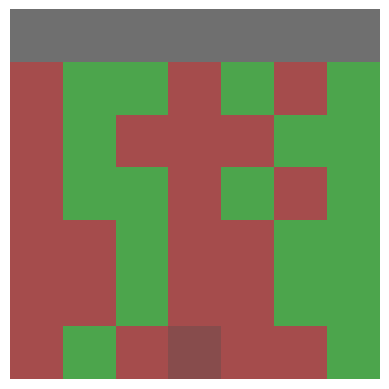

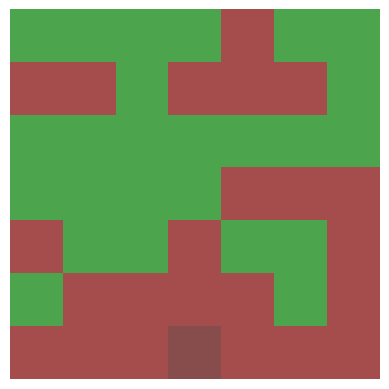

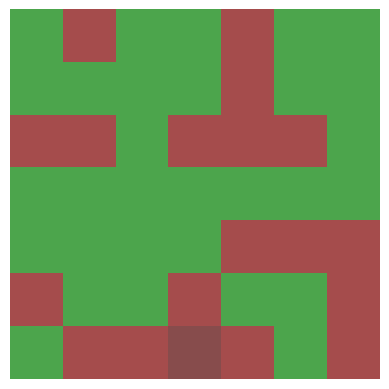

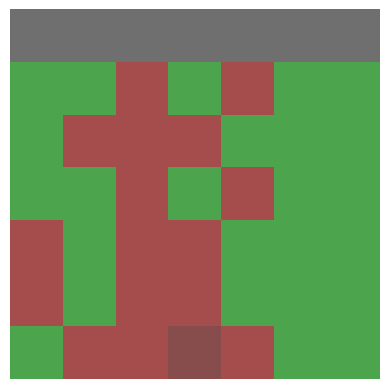

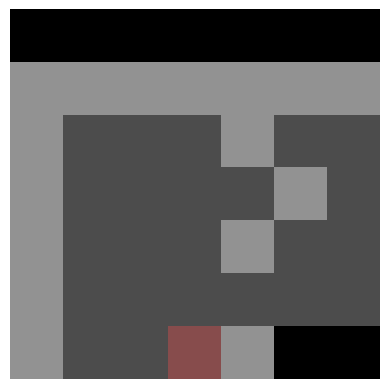

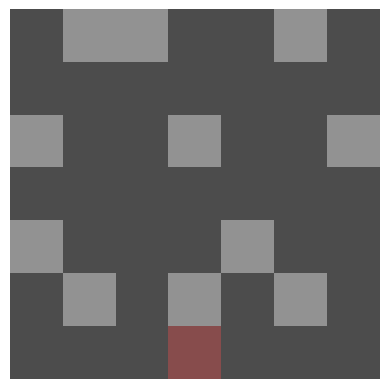

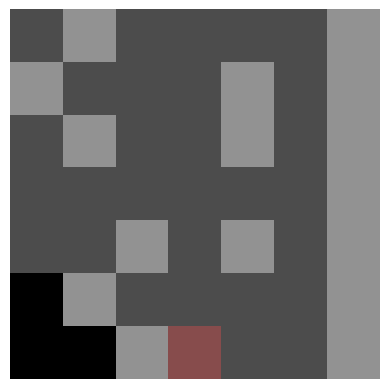

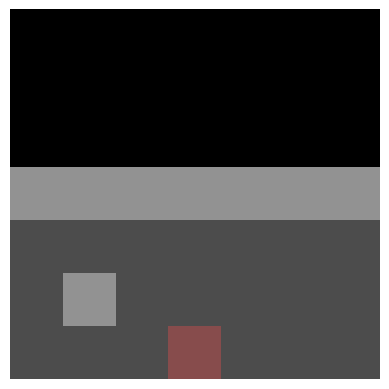

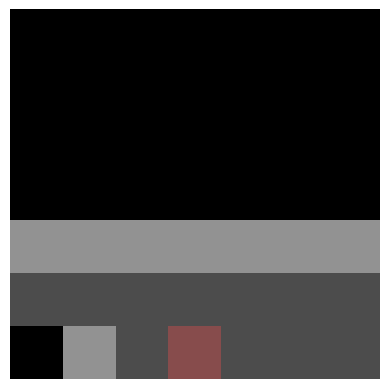

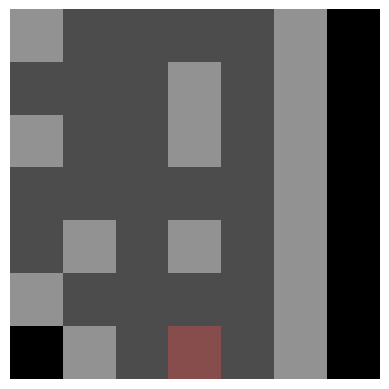

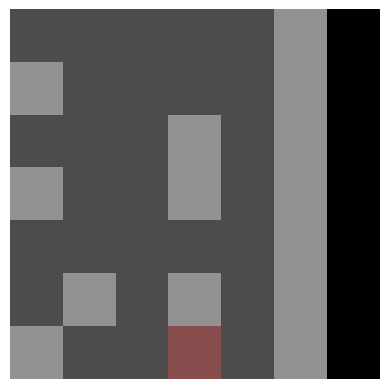

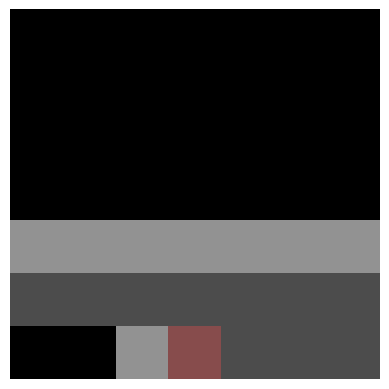

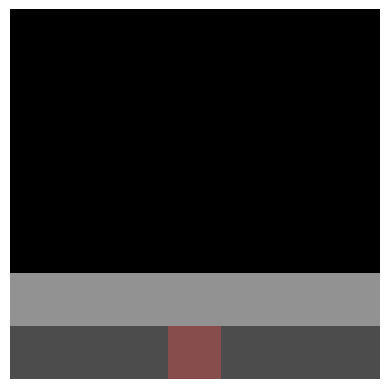

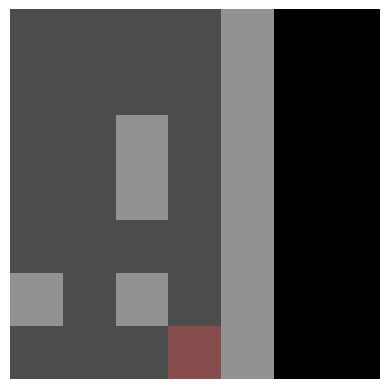

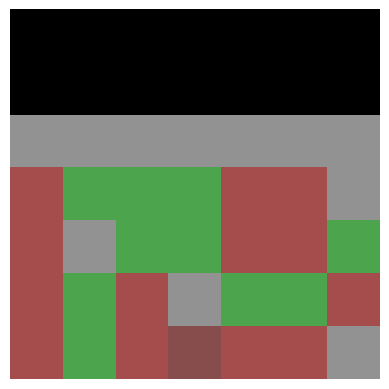

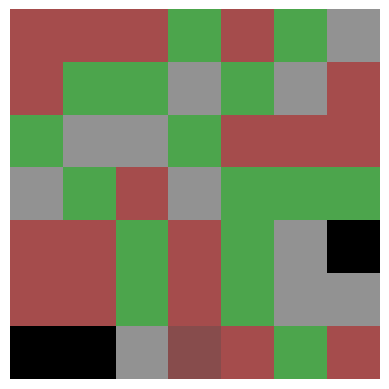

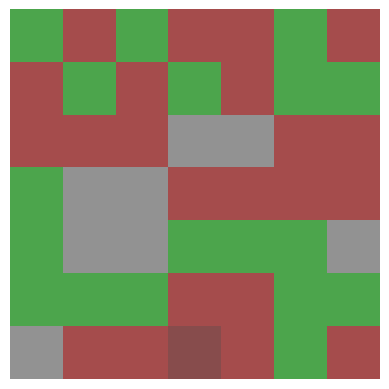

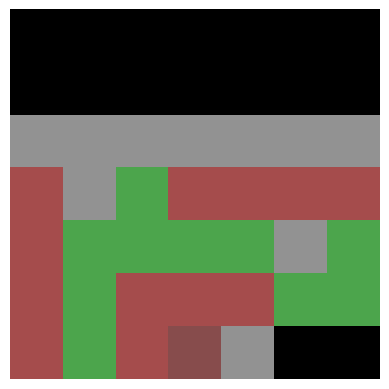

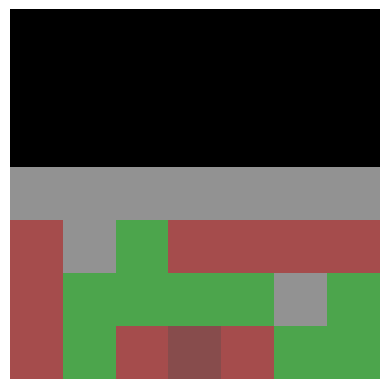

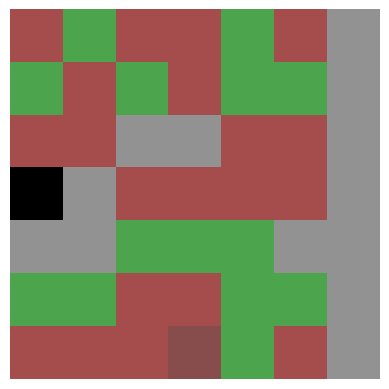

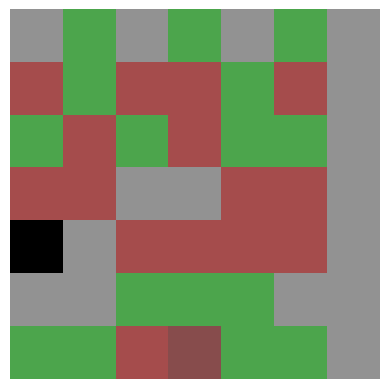

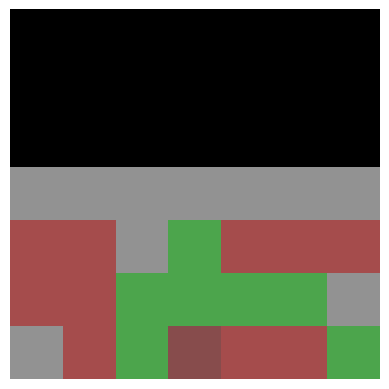

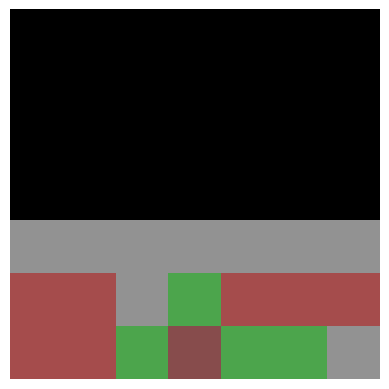

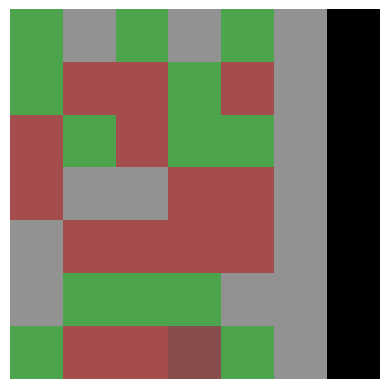

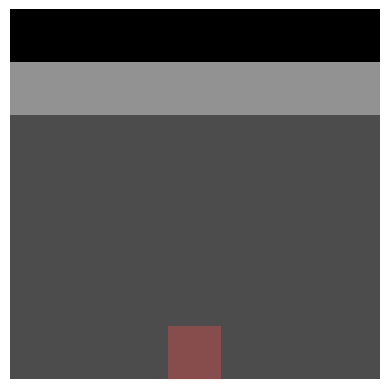

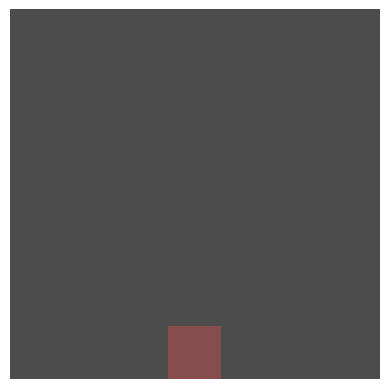

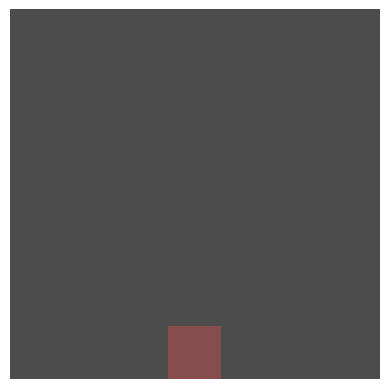

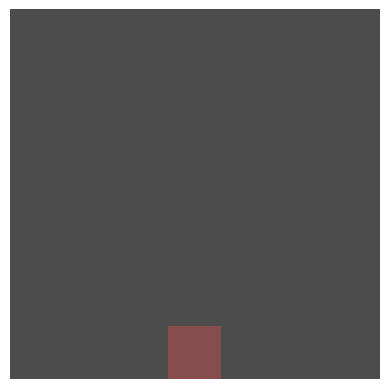

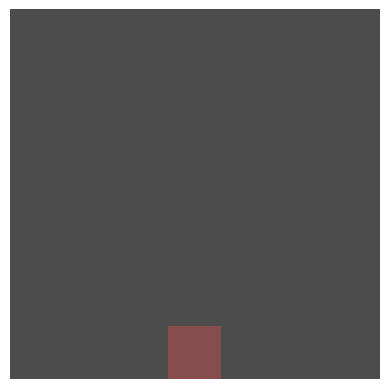

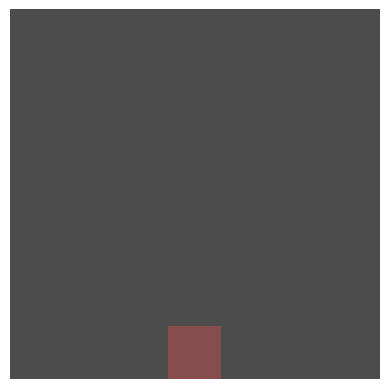

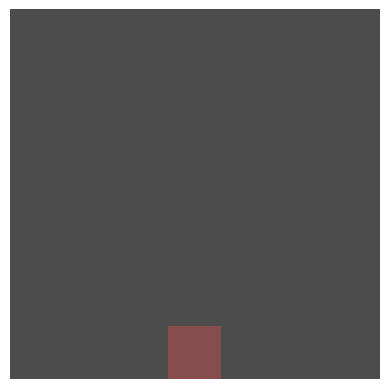

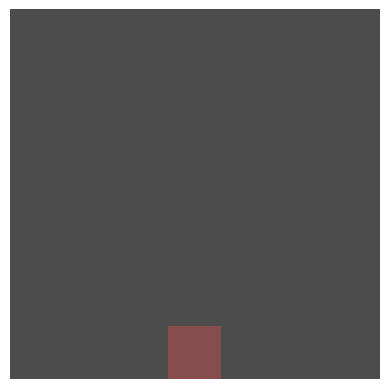

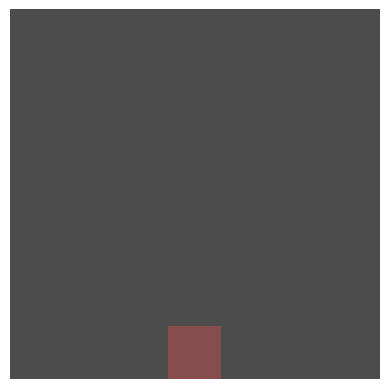

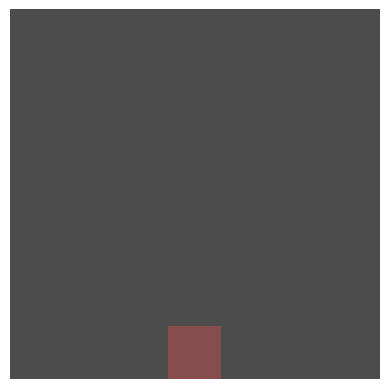

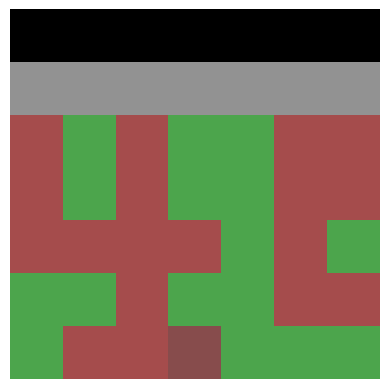

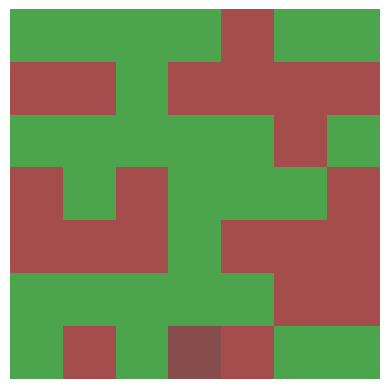

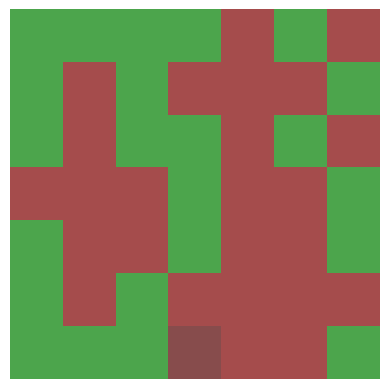

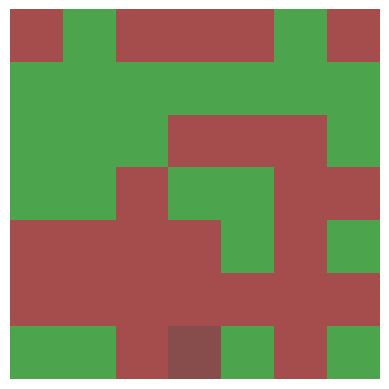

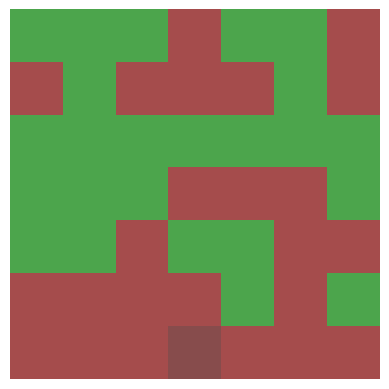

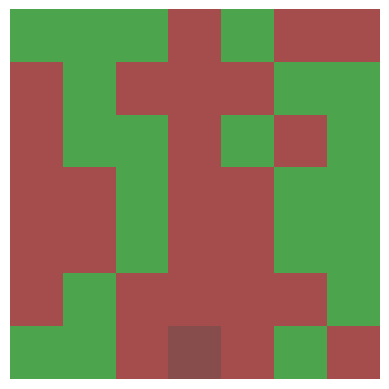

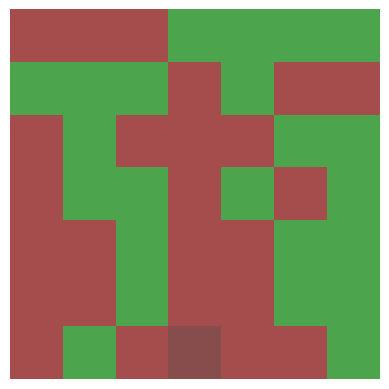

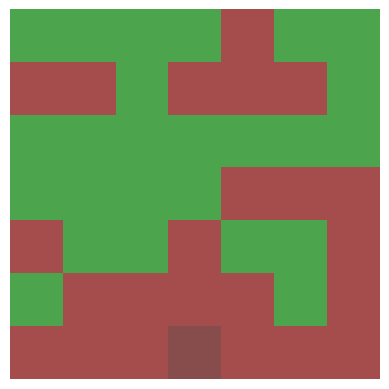

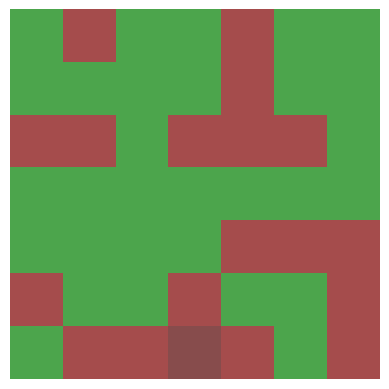

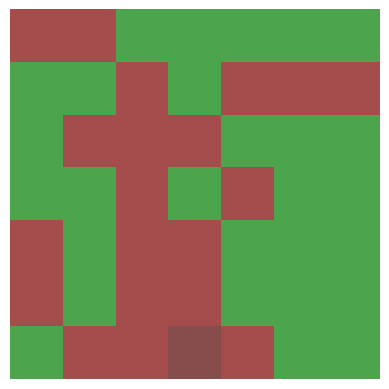

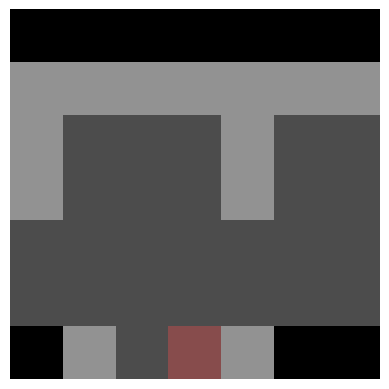

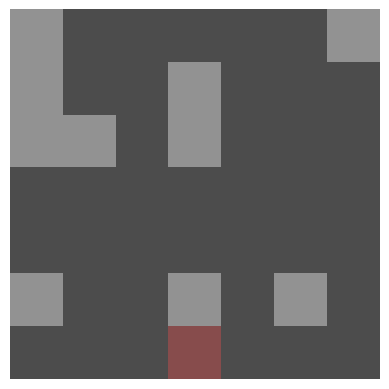

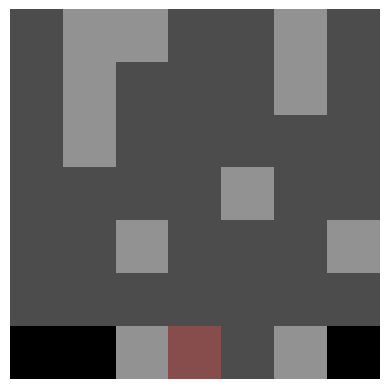

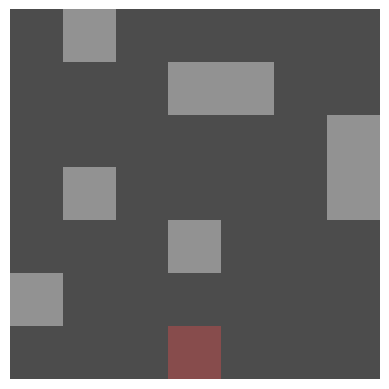

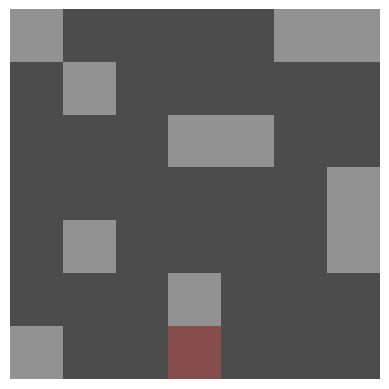

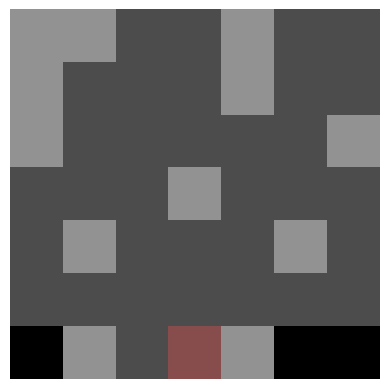

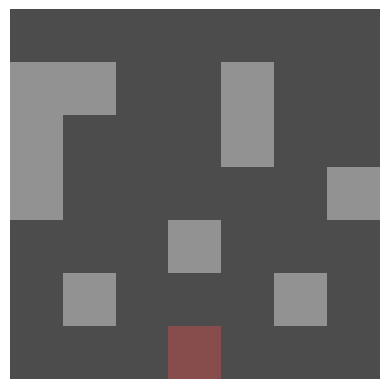

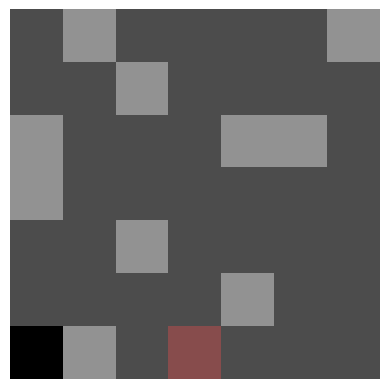

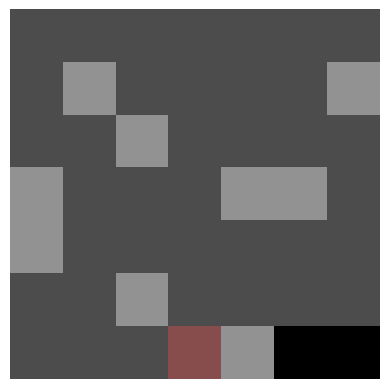

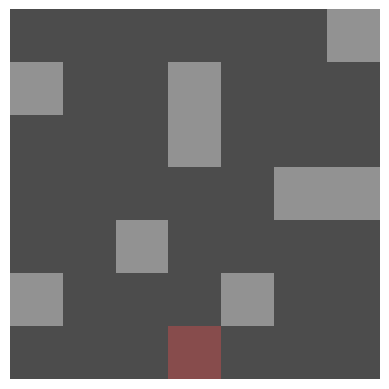

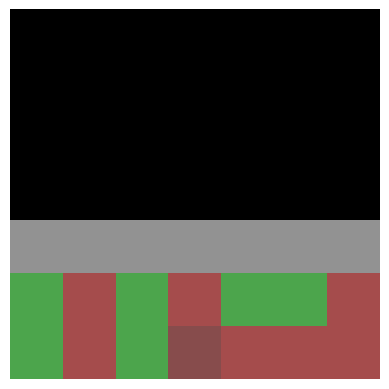

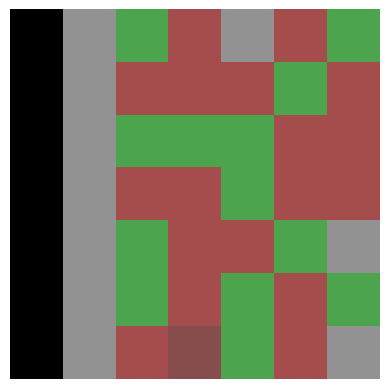

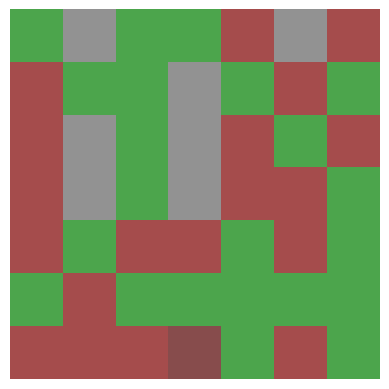

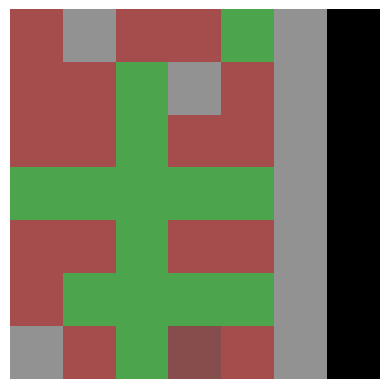

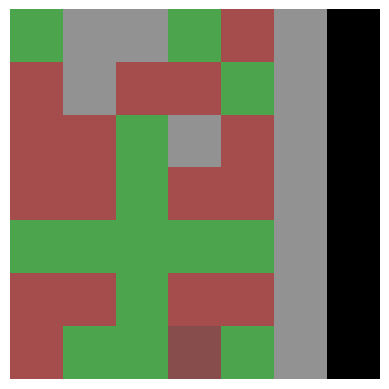

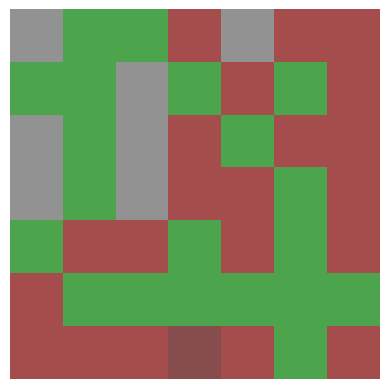

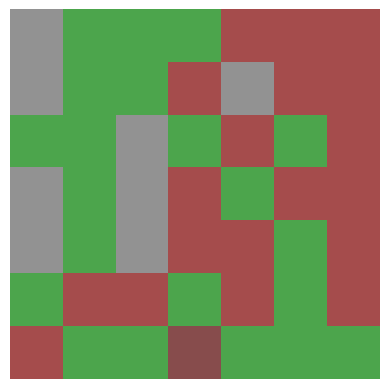

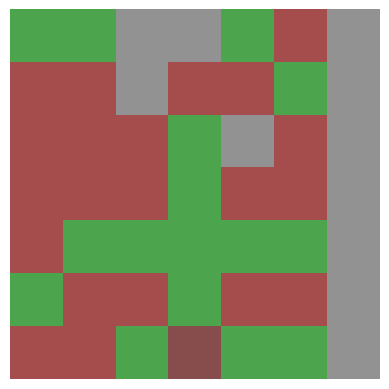

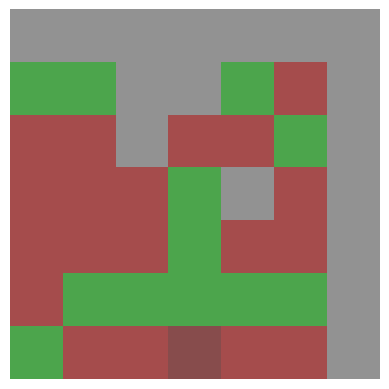

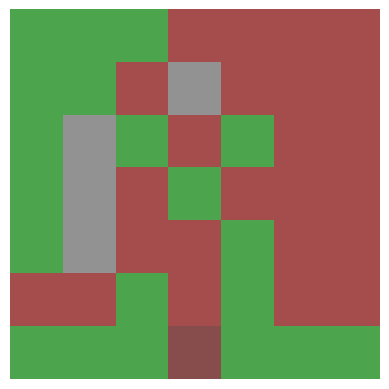

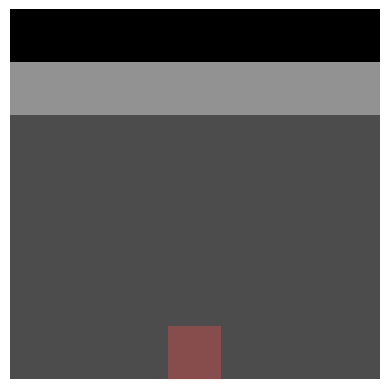

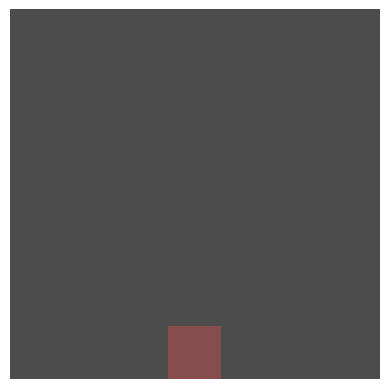

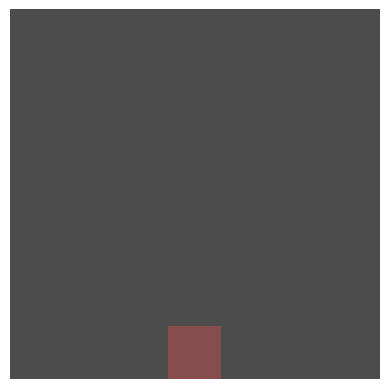

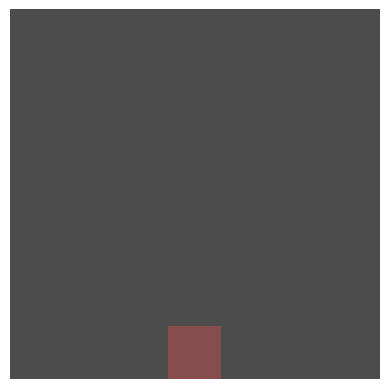

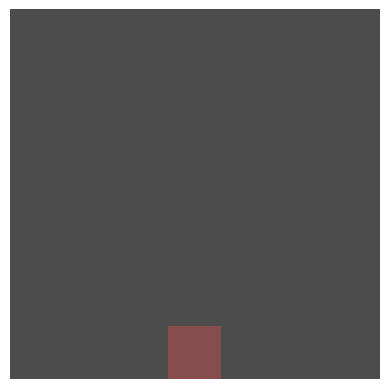

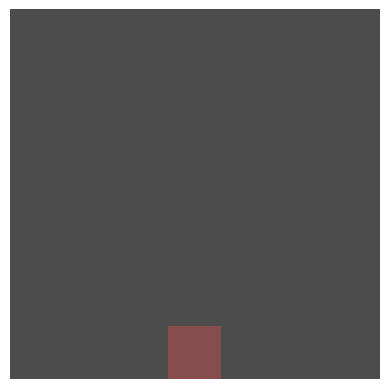

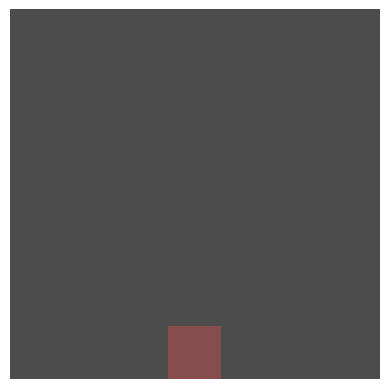

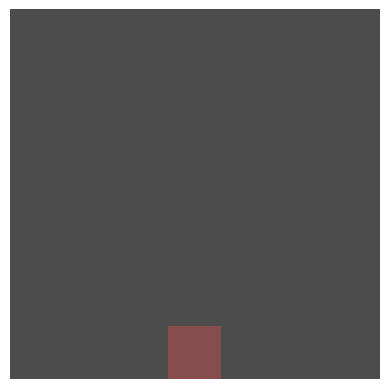

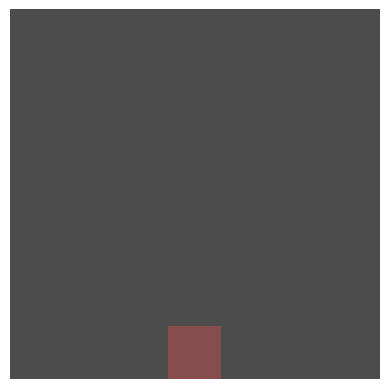

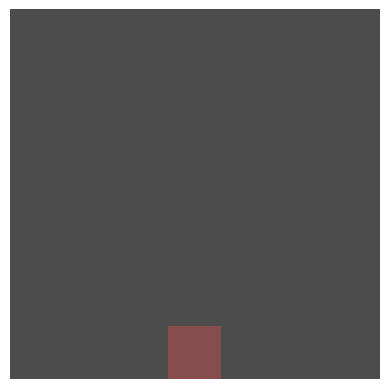

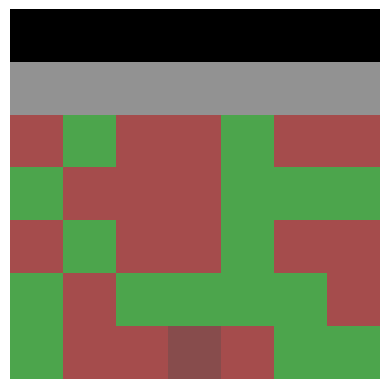

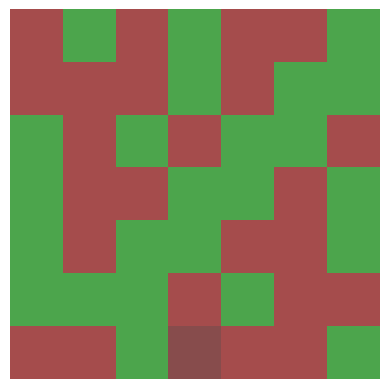

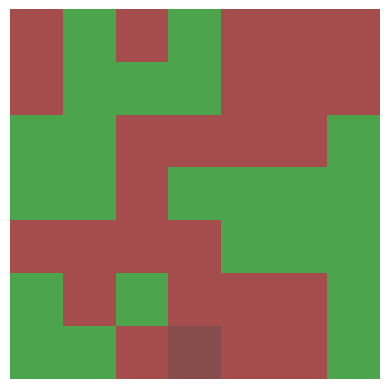

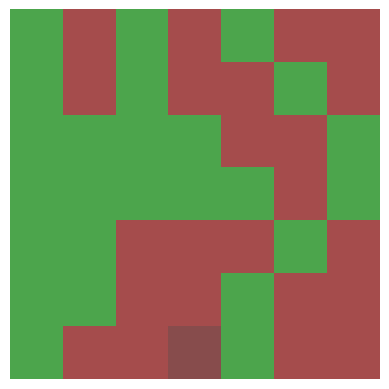

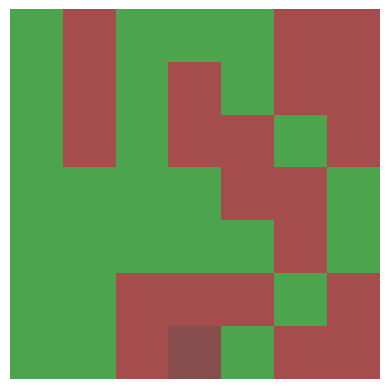

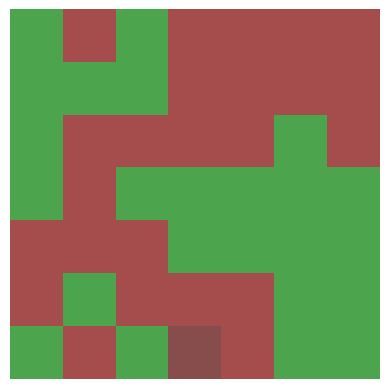

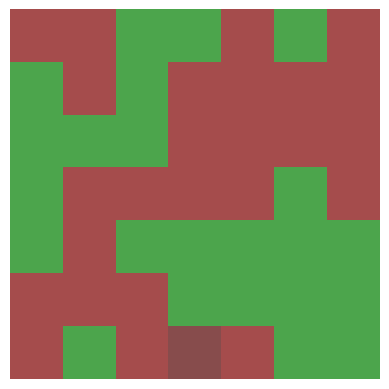

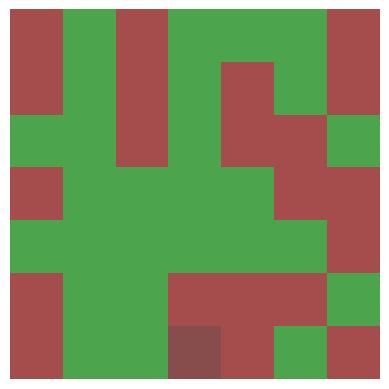

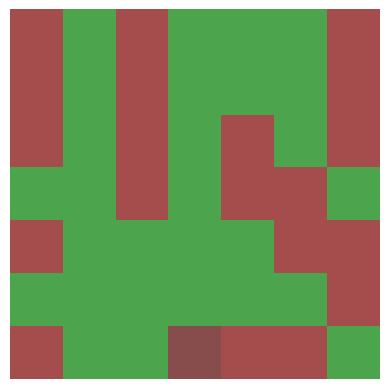

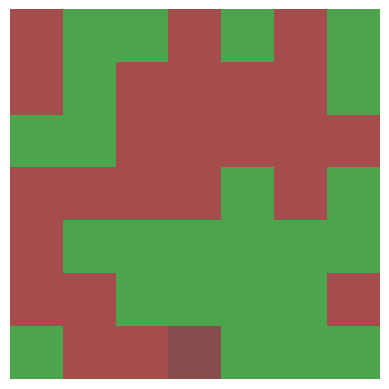

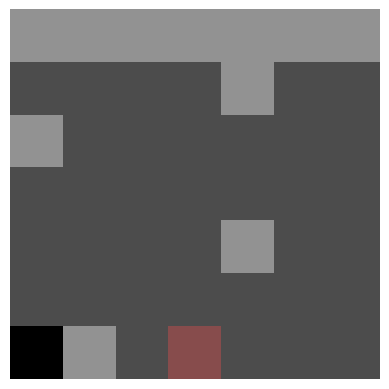

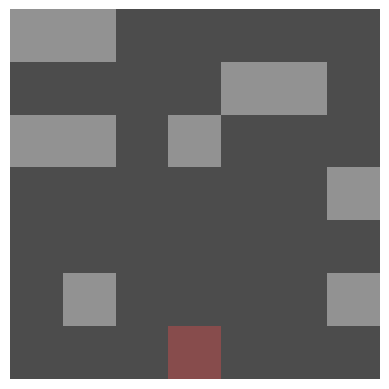

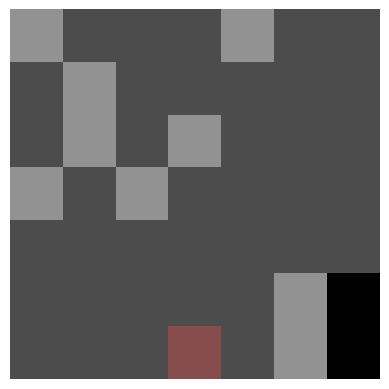

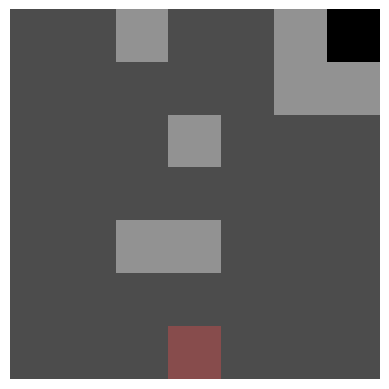

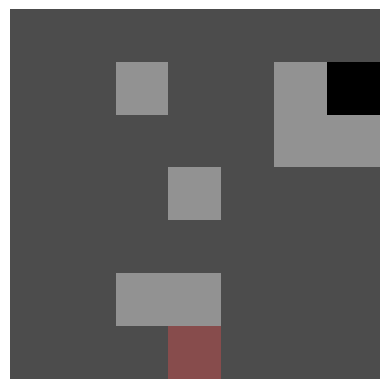

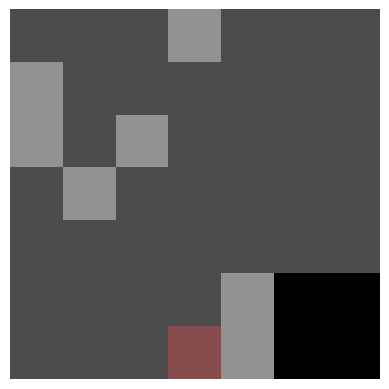

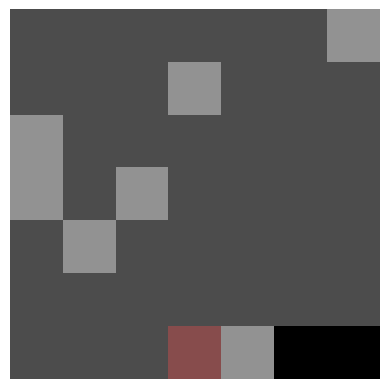

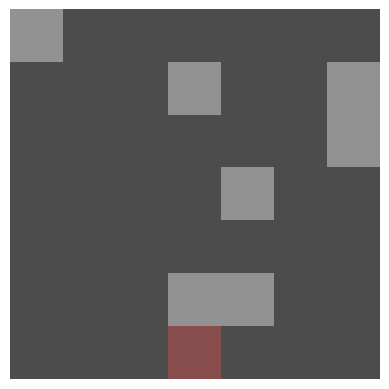

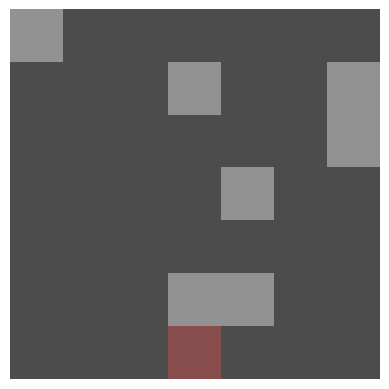

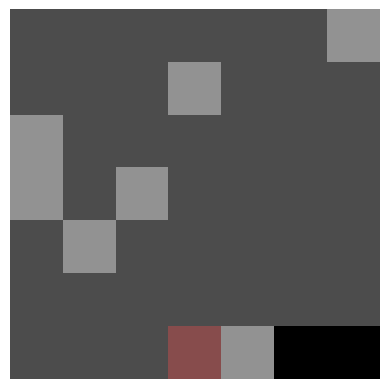

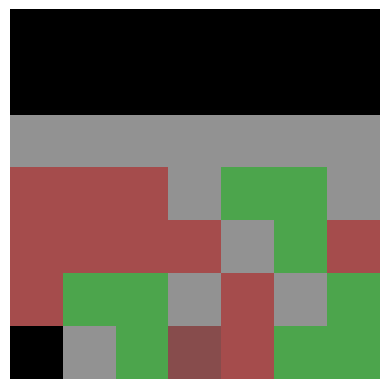

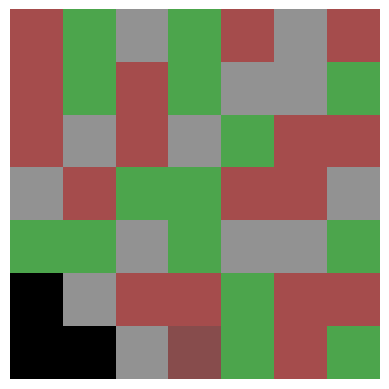

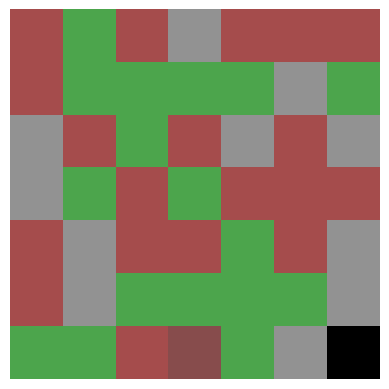

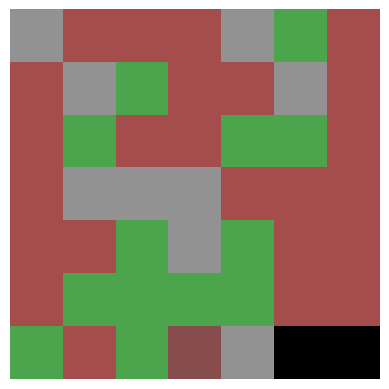

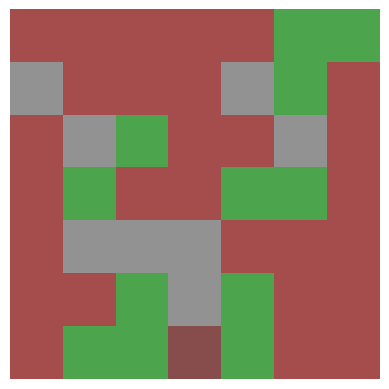

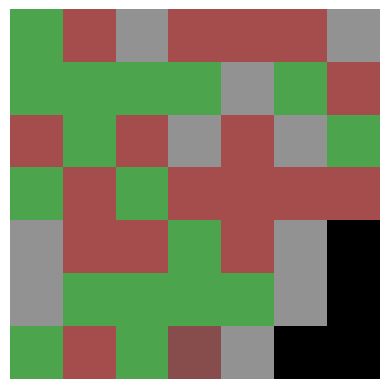

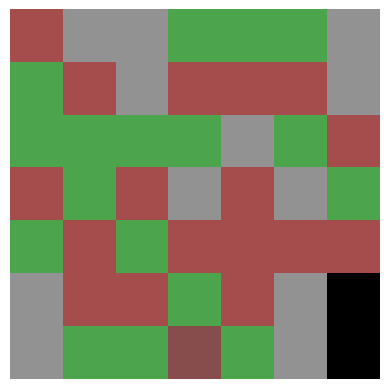

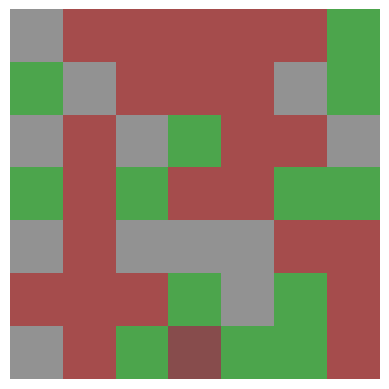

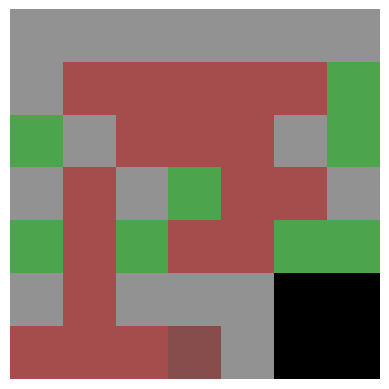

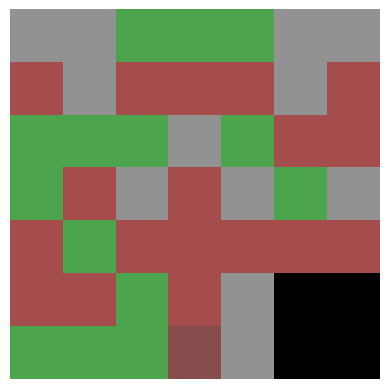

In [18]:
for c in range(len(map_labels)):
    ar = np.array(loaded_data[c][77243][0])[:,:-1]
    img = ar.reshape(-1,7, 7, 3).astype(np.uint8)

    for i in range(150,160):
        plt.imshow(img[i], interpolation='nearest')
        plt.axis('off') # Hide pixel coordinates
        plt.show()